In [2]:
#Импорт

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Input

In [3]:
#Задаем значения

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    shuffle=True,
    stratify=y_train,
    random_state=42
)

In [5]:
#Создание модели

model = Sequential([
    #БЛОК 0: ВХОД
    Input(shape=(28, 28, 1)),

    #БЛОК 1: АУГМЕНТАЦИЯ
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),

    #БЛОК 2: СВЕРТОЧНЫЙ СЛОЙ 1
    Conv2D(32, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    Conv2D(32, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    MaxPooling2D(2),

    #БЛОК 3: СВЕРТОЧНЫЙ СЛОЙ 2
    Conv2D(64, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    Conv2D(64, 3, padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.GlobalAveragePooling2D(),

    #БЛОК 4: КЛАССИФИКАТОР
    Dense(128, activation='relu'),
    Dropout(0.5),

    #БЛОК 5: ВЫХОД
    Dense(10, activation='softmax')
])

In [7]:
#Обучение модели

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cd = [
    callbacks.EarlyStopping(patience=5, min_delta=0.001, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('model.keras', save_best_only=True, verbose=1),
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=cd
)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Честный результат: {test_accuracy:.4f}, {test_loss:.4f}")

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7788 - loss: 0.7635
Epoch 1: val_loss improved from None to 1.96335, saving model to model.keras

Epoch 1: finished saving model to model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 117s 152ms/step - accuracy: 0.8838 - loss: 0.4208 - val_accuracy: 0.5048 - val_loss: 1.9634 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9542 - loss: 0.1648
Epoch 2: val_loss improved from 1.96335 to 0.91776, saving model to model.keras

Epoch 2: finished saving model to model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 105s 139ms/step - accuracy: 0.9576 - loss: 0.1540 - val_accuracy: 0.7639 - val_loss: 0.9178 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9654 - loss: 0.1222
Epoch 3: val_loss improved from 0.91776 to 0.25902, saving model to model.keras

Epoch 3: finished saving model to model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 104s 139ms/step - accuracy: 0.9660 - lo

Эпоха 1: val_loss = 1.9634
Эпоха 2: val_loss = 0.9178
Эпоха 3: val_loss = 0.2590
Эпоха 4: val_loss = 2.9485
Эпоха 5: val_loss = 0.8085
Эпоха 6: val_loss = 0.2498
Эпоха 7: val_loss = 0.4108
Эпоха 8: val_loss = 0.1644
Эпоха 9: val_loss = 0.1060
Эпоха 10: val_loss = 0.1350
Эпоха 11: val_loss = 0.5320
Эпоха 12: val_loss = 0.1600
Эпоха 13: val_loss = 0.0696
Эпоха 14: val_loss = 0.0392
Эпоха 15: val_loss = 0.1217
Эпоха 16: val_loss = 0.0764
Эпоха 17: val_loss = 0.0488
Эпоха 18: val_loss = 0.0496
Эпоха 19: val_loss = 0.0335
Эпоха 20: val_loss = 0.0337


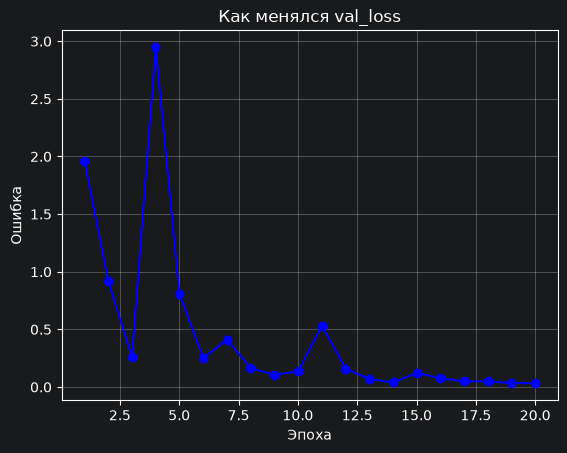

In [8]:
val_loss = history.history['val_loss']
epochs = range(1, len(val_loss) + 1)

for i, loss in enumerate(val_loss, 1):
    print(f"Эпоха {i}: val_loss = {loss:.4f}")

plt.plot(epochs, val_loss, 'b-o', label='val_loss')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.title('Как менялся val_loss')
plt.grid(True)
plt.show()
